# Multimodal Neural Network

This notebook combines the claim text and chart image in one Keras
model.

The model predicts:

- supported;
- refuted;
- not enough information.

## Architecture

The text branch uses `TextVectorization`, `Embedding` and dense
features.

The image branch uses convolution and pooling.

The two feature vectors are joined with `Concatenate` before the final
classification layers.

In [1]:
from pathlib import Path
import sys

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset_builder import (
    build_development_dataset,
)
from src.multimodal_neural_network import (
    LABEL_ORDER,
    build_multimodal_neural_network,
    create_multimodal_dataset,
    create_text_vectorizer,
    decode_predictions,
    encode_labels,
)

keras.utils.set_random_seed(42)

In [2]:
processed_directory = (
    project_root
    / "data"
    / "processed"
)

train_data = pd.read_csv(
    processed_directory
    / "train_chart_claim_dataset.csv"
)

validation_data = pd.read_csv(
    processed_directory
    / "validation_chart_claim_dataset.csv"
)

print("Training rows:", len(train_data))
print(
    "Validation rows:",
    len(validation_data),
)

train_data[
    [
        "image_path",
        "claim_text",
        "label",
    ]
].head()

Training rows: 252
Validation rows: 54


,image_path,claim_text,label
0,data/generated/charts/development/window_2019_...,The EU unemployment rate was higher in 2020 th...,supported
1,data/generated/charts/development/window_2019_...,The EU unemployment rate was lower in 2020 tha...,refuted
2,data/generated/charts/development/window_2019_...,The EU unemployment rate was higher in 2023 th...,not_enough_information
3,data/generated/charts/development/window_2019_...,The EU unemployment rate was lower in 2021 tha...,supported
4,data/generated/charts/development/window_2019_...,The EU unemployment rate was higher in 2021 th...,refuted


## Recreate chart images when needed

Generated PNG files remain outside Git and can be rebuilt from the
stored source data.

In [3]:
first_image_path = (
    project_root
    / train_data["image_path"].iloc[0]
)

if not first_image_path.exists():
    source_data = pd.read_csv(
        processed_directory
        / "eu_unemployment_2019_2025.csv"
    )

    build_development_dataset(
        data=source_data,
        output_directory=(
            project_root
            / "data"
            / "generated"
            / "charts"
            / "development"
        ),
    )

print(
    "First image exists:",
    first_image_path.exists(),
)

First image exists: True


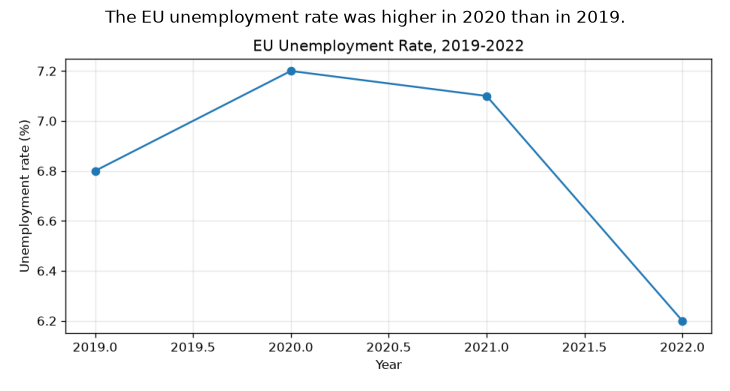

Label: supported


In [4]:
preview_row = train_data.iloc[0]

preview_image = plt.imread(
    project_root / preview_row["image_path"]
)

plt.figure(figsize=(8, 4))
plt.imshow(preview_image)
plt.axis("off")
plt.title(preview_row["claim_text"])
plt.tight_layout()
plt.show()

print("Label:", preview_row["label"])

## Prepare text and labels

The text vectorizer is adapted only with training claims.

In [5]:
train_text = (
    train_data["claim_text"]
    .astype(str)
    .to_numpy()
)

validation_text = (
    validation_data["claim_text"]
    .astype(str)
    .to_numpy()
)

train_labels = encode_labels(
    train_data["label"]
)

validation_labels = encode_labels(
    validation_data["label"]
)

vectorizer = create_text_vectorizer(
    training_text=train_text,
    max_tokens=1000,
    sequence_length=24,
)

print(
    "Vocabulary size:",
    len(vectorizer.get_vocabulary()),
)

Vocabulary size: 19


In [6]:
train_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in train_data["image_path"]
]

validation_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in validation_data["image_path"]
]

train_dataset = (
    create_multimodal_dataset(
        image_paths=train_image_paths,
        claim_texts=train_text,
        labels=train_labels,
        image_size=96,
        batch_size=16,
        shuffle=True,
        random_state=42,
    )
)

validation_dataset = (
    create_multimodal_dataset(
        image_paths=(
            validation_image_paths
        ),
        claim_texts=validation_text,
        labels=validation_labels,
        image_size=96,
        batch_size=16,
        shuffle=False,
    )
)

## Build the multimodal model

In [7]:
multimodal_model = (
    build_multimodal_neural_network(
        vectorizer=vectorizer,
        image_size=96,
        embedding_dimension=32,
        text_units=32,
        combined_units=64,
        dropout_rate=0.30,
        learning_rate=0.001,
    )
)

multimodal_model.summary()

Model: "multimodal_neural_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃       Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ chart_image (InputLayer) │ (None, 96, 96, 3)    │             0 │ -                     │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ pixel_rescaling          │ (None, 96, 96, 3)    │             0 │ chart_image[0][0]     │
│ (Rescaling)              │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_conv_1 (Conv2D)    │ (None, 96, 96, 16)   │           448 │ pixel_rescaling[0][0] │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ claim_text (InputLayer)  │ (None)               │             0 │ -                     │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_pool_1             │ (None, 48, 48, 16)   │             0 │ image_conv_1[0][0]    │
│ (MaxPooling2D)           │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ text_vectorization       │ (None, 24)           │             0 │ claim_text[0][0]      │
│ (TextVectorization)      │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_conv_2 (Conv2D)    │ (None, 48, 48, 32)   │         4,640 │ image_pool_1[0][0]    │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ token_embedding          │ (None, 24, 32)       │           608 │ text_vectorization[0… │
│ (Embedding)              │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ not_equal (NotEqual)     │ (None, 24)           │             0 │ text_vectorization[0… │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_pool_2             │ (None, 24, 24, 32)   │             0 │ image_conv_2[0][0]    │
│ (MaxPooling2D)           │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ text_average_pooling     │ (None, 32)           │             0 │ token_embedding[0][0… │
│ (GlobalAveragePooling1D) │                      │               │ not_equal[0][0]       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_conv_3 (Conv2D)    │ (None, 24, 24, 64)   │        18,496 │ image_pool_2[0][0]    │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ text_dense (Dense)       │ (None, 32)           │         1,056 │ text_average_pooling… │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_average_pooling    │ (None, 64)           │             0 │ image_conv_3[0][0]    │
│ (GlobalAveragePooling2D) │                      │               │                       │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ text_dropout (Dropout)   │ (None, 32)           │             0 │ text_dense[0][0]      │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ image_dropout (Dropout)  │ (None, 64)           │             0 │ image_average_poolin… │
├──────────────────────────┼──────────────────────┼───────────────┼───────────────────────┤
│ multimodal_concatenation │ (None, 96)           │             0 │ text_dropout[0][0],   │
│ (Concatenate)            │                

 Total params: 31,651 (123.64 KB)

 Trainable params: 31,651 (123.64 KB)

 Non-trainable params: 0 (0.00 B)

## Training

Early stopping monitors validation loss and restores the best weights.

In [8]:
early_stopping = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
)

history = multimodal_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping],
    verbose=0,
)

print(
    "Epochs completed:",
    len(history.history["loss"]),
)

C:\Users\stana\Desktop\chart-claim-verification-bg\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epochs completed: 30


In [9]:
history_data = pd.DataFrame(
    history.history
)

history_data.index = (
    history_data.index + 1
)

history_data.index.name = "epoch"

history_data.tail()

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
26,0.845238,0.526940,0.888889,0.523735
27,0.841270,0.480742,0.888889,0.512016
28,0.841270,0.498654,0.888889,0.496954
29,0.853175,0.499800,0.888889,0.498596
30,0.865079,0.497589,0.888889,0.470736


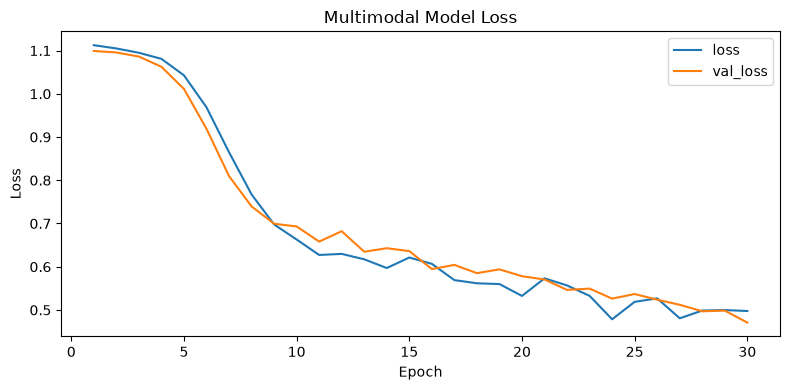

In [10]:
history_data[
    ["loss", "val_loss"]
].plot(
    figsize=(8, 4),
)

plt.title("Multimodal Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

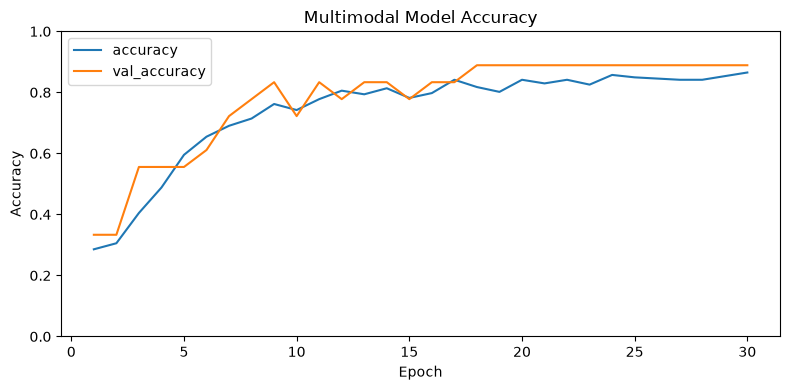

In [11]:
history_data[
    ["accuracy", "val_accuracy"]
].plot(
    figsize=(8, 4),
)

plt.title(
    "Multimodal Model Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Validation evaluation

In [12]:
validation_probabilities = (
    multimodal_model.predict(
        validation_dataset,
        verbose=0,
    )
)

validation_indices = np.argmax(
    validation_probabilities,
    axis=1,
)

validation_predictions = (
    decode_predictions(
        validation_indices
    )
)

validation_accuracy = (
    accuracy_score(
        validation_data["label"],
        validation_predictions,
    )
)

validation_macro_f1 = f1_score(
    validation_data["label"],
    validation_predictions,
    average="macro",
    zero_division=0,
)

multimodal_metrics = pd.DataFrame(
    [
        {
            "model": (
                "Keras multimodal "
                "neural network"
            ),
            "accuracy": (
                validation_accuracy
            ),
            "macro_f1": (
                validation_macro_f1
            ),
            "evaluation_split": (
                "validation"
            ),
        }
    ]
)

multimodal_metrics

,model,accuracy,macro_f1,evaluation_split
0,Keras multimodal neural network,0.888889,0.8885,validation


In [13]:
validation_report = pd.DataFrame(
    classification_report(
        validation_data["label"],
        validation_predictions,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
).transpose()

validation_report

,precision,recall,f1-score,support
supported,0.833333,0.833333,0.833333,18.000000
refuted,1.000000,0.833333,0.909091,18.000000
not_enough_information,0.857143,1.000000,0.923077,18.000000
accuracy,0.888889,0.888889,0.888889,0.888889
macro avg,0.896825,0.888889,0.888500,54.000000
weighted avg,0.896825,0.888889,0.888500,54.000000


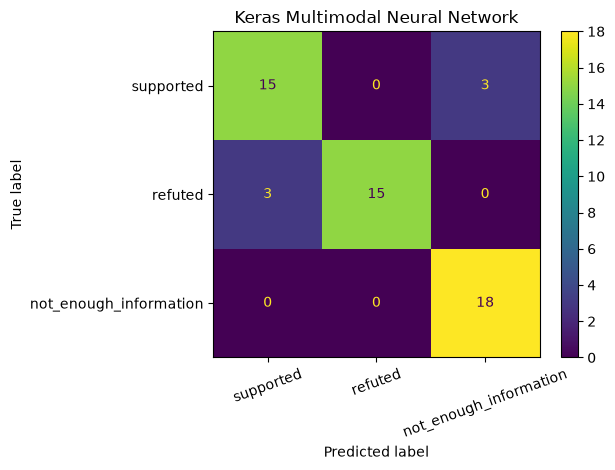

In [14]:
validation_matrix = (
    confusion_matrix(
        validation_data["label"],
        validation_predictions,
        labels=LABEL_ORDER,
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        validation_matrix
    ),
    display_labels=LABEL_ORDER,
).plot(
    xticks_rotation=20,
)

plt.title(
    "Keras Multimodal Neural Network"
)
plt.tight_layout()
plt.show()

## Comparison with previous models

In [15]:
comparison_path = (
    project_root
    / "reports"
    / "model_validation_comparison.csv"
)

model_comparison = pd.read_csv(
    comparison_path
)

model_comparison = (
    model_comparison.loc[
        model_comparison["model"]
        != (
            "Keras multimodal "
            "neural network"
        )
    ]
)

model_comparison = pd.concat(
    [
        model_comparison,
        multimodal_metrics,
    ],
    ignore_index=True,
)

model_comparison

,model,accuracy,macro_f1,evaluation_split
0,Majority baseline,0.333333,0.166667,validation
1,TF-IDF + Logistic Regression,0.777778,0.772339,validation
2,Keras text neural network,0.833333,0.827894,validation
3,Keras CNN image model,0.333333,0.166667,validation
4,Keras multimodal neural network,0.888889,0.888500,validation


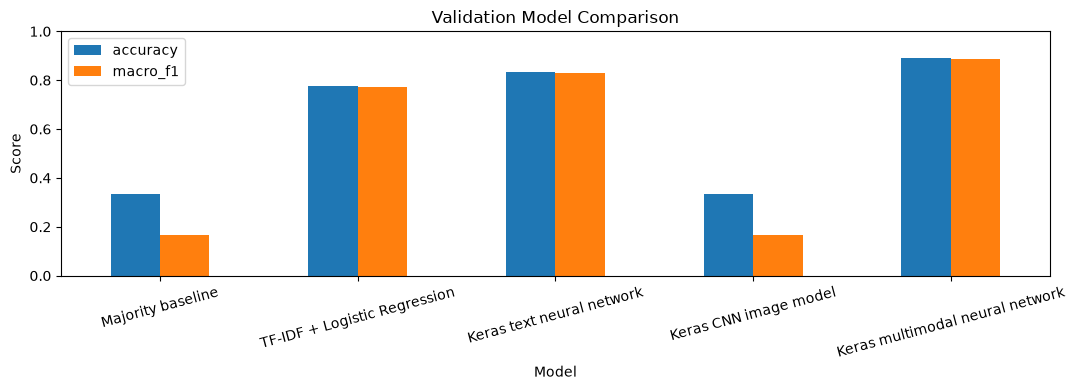

In [16]:
model_comparison.set_index(
    "model"
)[
    ["accuracy", "macro_f1"]
].plot(
    kind="bar",
    figsize=(11, 4),
)

plt.title(
    "Validation Model Comparison"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Save results

The trained `.keras` model remains local and is ignored by Git.

In [17]:
reports_directory = (
    project_root / "reports"
)

models_directory = (
    project_root / "models"
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True,
)

models_directory.mkdir(
    parents=True,
    exist_ok=True,
)

history_data.to_csv(
    reports_directory
    / (
        "multimodal_neural_network_"
        "history.csv"
    )
)

multimodal_metrics.to_csv(
    reports_directory
    / (
        "multimodal_neural_network_"
        "validation_metrics.csv"
    ),
    index=False,
)

validation_report.to_csv(
    reports_directory
    / (
        "multimodal_neural_network_"
        "validation_report.csv"
    )
)

pd.DataFrame(
    validation_matrix,
    index=[
        f"actual_{label}"
        for label in LABEL_ORDER
    ],
    columns=[
        f"predicted_{label}"
        for label in LABEL_ORDER
    ],
).to_csv(
    reports_directory
    / (
        "multimodal_neural_network_"
        "validation_confusion_matrix.csv"
    )
)

model_comparison.to_csv(
    reports_directory
    / "model_validation_comparison.csv",
    index=False,
)

multimodal_model.save(
    models_directory
    / "multimodal_neural_network.keras"
)

print(
    "Multimodal model and reports saved."
)

Multimodal model and reports saved.


## Result

The validation result must be compared with both the text-only and
image-only neural networks.

The multimodal model is the central architecture of the project, but a
small development dataset may not provide a clear advantage over the
text-only model.

The test split remains untouched.